# Naive Bayes & MLP — Demand Classification

**Models:** Gaussian Naive Bayes · Multi-Layer Perceptron  
**Target:** `demand_label` (binary: 0 = low demand, 1 = high demand)  
**Tuning:** Optuna (weighted-F1 objective)

> **Naive Bayes note:** GaussianNB assumes feature independence and Gaussian distributions. With label-encoded categoricals and scaled numerics, performance may be moderate. It serves as a fast probabilistic baseline.  
> **MLP note:** The neural net benefits from the StandardScaling already applied in postprocessing.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.naive_bayes    import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score,
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('dark_background')
SEED = 42

## 1. Load Data

In [2]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
 
SEED       = 42
TARGET     = 'demand_label'
MODEL_TYPE = 'boost'
DATA_DIR   = '/kaggle/input/datasets/abdulrahmanmostafa10/data-bnb/'
# DATA_DIR = '../data/splits/'
 
train_df = pd.read_csv(DATA_DIR + 'train.csv', low_memory=False)
test_df  = pd.read_csv(DATA_DIR + 'test.csv',  low_memory=False)
 
DROP_COLS  = [
    'demand_label', 'demand_label_3', 'demand_score',
    'Price_log', 'Price_original',
]
DROP_COLS += [c for c in train_df.columns if c.endswith('_raw')]
DROP_COLS += [c for c in train_df.columns if 'Parsed_Amenities' in c]
 
feature_cols = [c for c in train_df.columns if c not in DROP_COLS]
 
# Sanitize column names (required for LightGBM)
def sanitize(cols):
    return {c: re.sub(r'[^A-Za-z0-9_]+', '_', c) for c in cols}
 
rename_map   = sanitize(feature_cols)
train_df     = train_df.rename(columns=rename_map)
test_df      = test_df.rename(columns=rename_map)
feature_cols = list(rename_map.values())
 
X_all  = train_df[feature_cols]
y_all  = train_df[TARGET]
X_test = test_df[feature_cols]
y_test = test_df[TARGET]
 
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=SEED, stratify=y_all
)
 
# Class imbalance weight (used in XGBoost and LightGBM)
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()
scale_pos_weight = neg / pos if pos > 0 else 1.0
 
print(f'Train : {X_train.shape} | Val : {X_val.shape} | Test : {X_test.shape}')
print(f'Class balance — train : {y_train.value_counts(normalize=True).round(3).to_dict()}')
print(f'Class balance — val   : {y_val.value_counts(normalize=True).round(3).to_dict()}')
print(f'Class balance — test  : {y_test.value_counts(normalize=True).round(3).to_dict()}')
print(f'Remaining nulls — train: {X_train.isna().sum().sum()}')
print(f'Remaining nulls — test : {X_test.isna().sum().sum()}')
print(f'Features used : {len(feature_cols)}')
print(f'scale_pos_weight = {scale_pos_weight:.4f}')

Train : (311661, 95) | Val : (77916, 95) | Test : (97395, 95)
Class balance — train : {0: 0.5, 1: 0.5}
Class balance — val   : {0: 0.5, 1: 0.5}
Class balance — test  : {0: 0.5, 1: 0.5}
Remaining nulls — train: 0
Remaining nulls — test : 0
Features used : 95
scale_pos_weight = 1.0007


---
## 2. Gaussian Naive Bayes

In [3]:
def objective_nb(trial):
    var_smoothing = trial.suggest_float('var_smoothing', 1e-11, 1e-7, log=True)
    model = GaussianNB(var_smoothing=var_smoothing)
    model.fit(X_train, y_train)
    return f1_score(y_val, model.predict(X_val), average='weighted')

study_nb = optuna.create_study(direction='maximize')
study_nb.optimize(objective_nb, n_trials=200, n_jobs=2)
print(f'Best Val F1 (NB) : {study_nb.best_value:.4f}')
print(f'Best Params      : {study_nb.best_params}')

Best Val F1 (NB) : 0.5181
Best Params      : {'var_smoothing': 9.989756231277343e-08}


In [4]:
X_combined = pd.concat([X_train, X_val])
y_combined = pd.concat([y_train, y_val])

nb_model = GaussianNB(**study_nb.best_params)
nb_model.fit(X_combined, y_combined)
print('Gaussian NB trained.')

Gaussian NB trained.


=== Gaussian Naive Bayes ===
Accuracy      : 0.5834
F1 (weighted) : 0.5196
              precision    recall  f1-score   support

         Low       0.81      0.22      0.34     48714
        High       0.55      0.95      0.69     48681

    accuracy                           0.58     97395
   macro avg       0.68      0.58      0.52     97395
weighted avg       0.68      0.58      0.52     97395



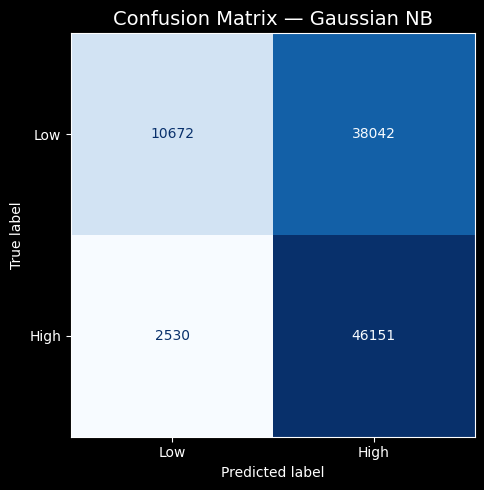

In [5]:
y_pred_nb = nb_model.predict(X_test)

print('=== Gaussian Naive Bayes ===')
print(f'Accuracy      : {accuracy_score(y_test, y_pred_nb):.4f}')
print(f'F1 (weighted) : {f1_score(y_test, y_pred_nb, average="weighted"):.4f}')
print(classification_report(y_test, y_pred_nb, target_names=['Low','High']))

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_nb), display_labels=['Low','High']).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Gaussian NB', fontsize=14); plt.tight_layout(); plt.show()

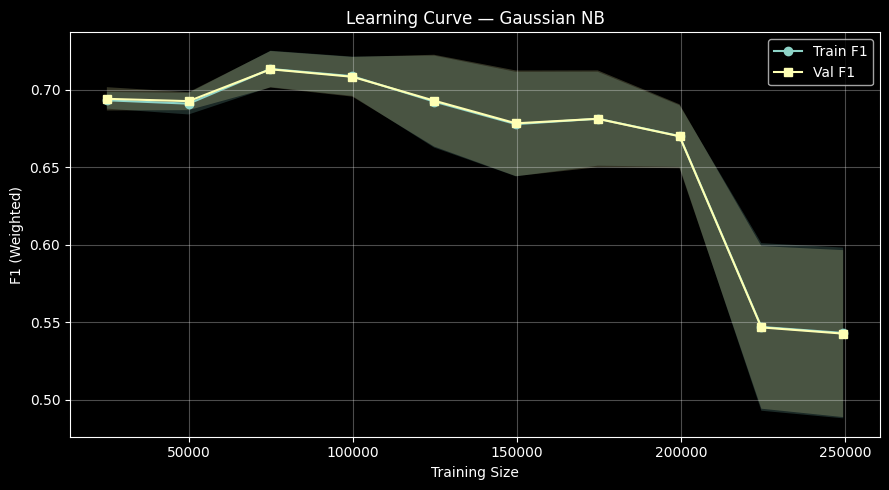

In [6]:
lc_nb = GaussianNB(**study_nb.best_params)
ts, tr_s, val_s = learning_curve(
    lc_nb, X_train, y_train, cv=5, scoring='f1_weighted',
    train_sizes=np.linspace(0.1,1.0,10), n_jobs=-1,
)
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(ts, tr_s.mean(1), 'o-', label='Train F1'); ax.fill_between(ts, tr_s.mean(1)-tr_s.std(1), tr_s.mean(1)+tr_s.std(1), alpha=0.2)
ax.plot(ts, val_s.mean(1), 's-', label='Val F1');   ax.fill_between(ts, val_s.mean(1)-val_s.std(1), val_s.mean(1)+val_s.std(1), alpha=0.2)
ax.set(xlabel='Training Size', ylabel='F1 (Weighted)', title='Learning Curve — Gaussian NB')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 3. MLP (Neural Network)

In [7]:
def objective_mlp(trial):
    params = {
        'hidden_layer_sizes': trial.suggest_categorical(
            'hidden_layer_sizes',
            [(64,), (128,), (64, 32), (128, 64), (256, 128), (128, 64, 32)]
        ),
        'activation':         trial.suggest_categorical('activation', ['relu', 'tanh']),
        'alpha':              trial.suggest_float('alpha',             1e-5, 1e-1, log=True),
        'learning_rate_init': trial.suggest_float('learning_rate_init',1e-4, 1e-1, log=True),
        'batch_size':         trial.suggest_categorical('batch_size',  [64, 128, 256]),
    }
    model = MLPClassifier(
        **params, solver='adam', max_iter=500,
        shuffle=True, random_state=SEED, early_stopping=True,
        validation_fraction=0.1, n_iter_no_change=15,
    )
    model.fit(X_train, y_train)
    return f1_score(y_val, model.predict(X_val), average='weighted')

study_mlp = optuna.create_study(direction='maximize')
study_mlp.optimize(objective_mlp, n_trials=50, n_jobs=2)
print(f'Best Val F1 (MLP) : {study_mlp.best_value:.4f}')
print(f'Best Params       : {study_mlp.best_params}')

/tmp/ipykernel_16/3444981775.py:3: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64,) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
/tmp/ipykernel_16/3444981775.py:3: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (128,) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
/tmp/ipykernel_16/3444981775.py:3: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (64, 32) which is of type tuple.
  'hidden_layer_sizes': trial.suggest_categorical(
/tmp/ipykernel_16/3444981775.py:3: UserWarning: Choices for a categorical distribution should be a tuple of None, bool, int, float and str for persistent storage but contains (128, 64) which is of type tuple.
  'hidden_layer_siz

Best Val F1 (MLP) : 0.9094
Best Params       : {'hidden_layer_sizes': (64, 32), 'activation': 'relu', 'alpha': 0.005930835975178951, 'learning_rate_init': 0.0005738863683313153, 'batch_size': 64}


In [8]:
mlp_model = MLPClassifier(
    **study_mlp.best_params,
    solver='adam', max_iter=1000,
    shuffle=True, random_state=SEED,
)
mlp_model.fit(X_combined, y_combined)
print(f'MLP trained. Iterations: {mlp_model.n_iter_}')

MLP trained. Iterations: 105


=== MLP ===
Accuracy      : 0.9066
F1 (weighted) : 0.9066
              precision    recall  f1-score   support

         Low       0.91      0.90      0.91     48714
        High       0.90      0.92      0.91     48681

    accuracy                           0.91     97395
   macro avg       0.91      0.91      0.91     97395
weighted avg       0.91      0.91      0.91     97395



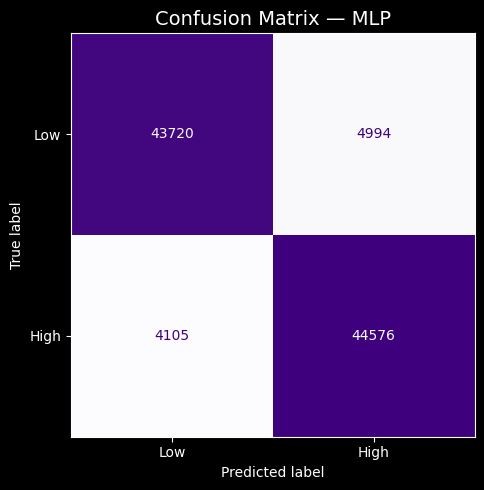

In [9]:
y_pred_mlp = mlp_model.predict(X_test)

print('=== MLP ===')
print(f'Accuracy      : {accuracy_score(y_test, y_pred_mlp):.4f}')
print(f'F1 (weighted) : {f1_score(y_test, y_pred_mlp, average="weighted"):.4f}')
print(classification_report(y_test, y_pred_mlp, target_names=['Low','High']))

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_mlp), display_labels=['Low','High']).plot(ax=ax, colorbar=False, cmap='Purples')
ax.set_title('Confusion Matrix — MLP', fontsize=14); plt.tight_layout(); plt.show()

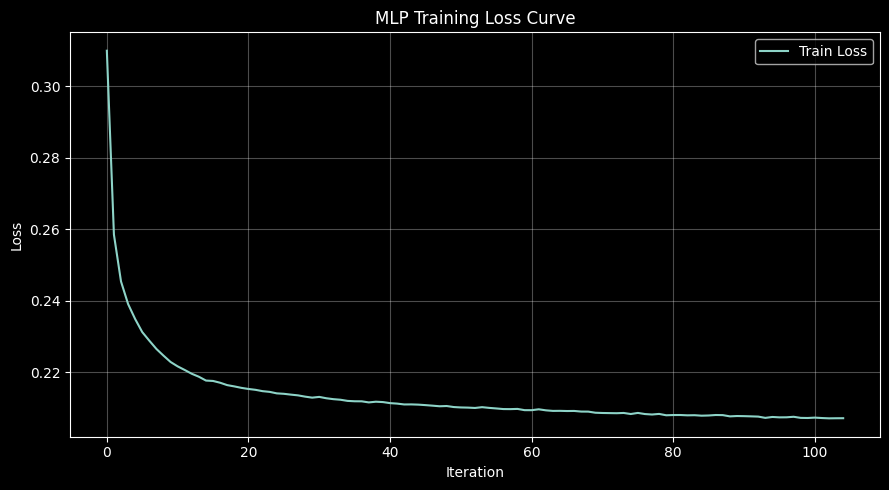

In [10]:
# Training loss curve (available for adam/sgd solvers)
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(mlp_model.loss_curve_, label='Train Loss')
ax.set(xlabel='Iteration', ylabel='Loss', title='MLP Training Loss Curve')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

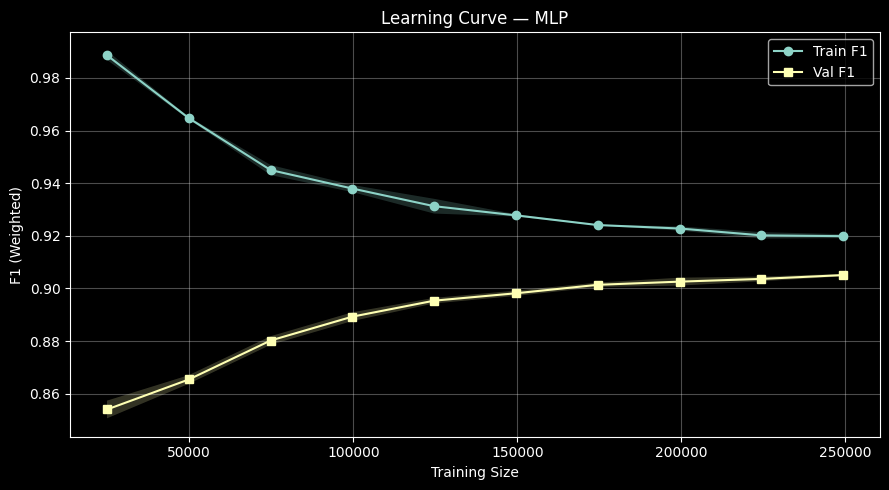

In [11]:
lc_mlp = MLPClassifier(**study_mlp.best_params, solver='adam', max_iter=500, shuffle=True, random_state=SEED)
ts, tr_s, val_s = learning_curve(
    lc_mlp, X_train, y_train, cv=5, scoring='f1_weighted',
    train_sizes=np.linspace(0.1,1.0,10), n_jobs=-1,
)
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(ts, tr_s.mean(1), 'o-', label='Train F1'); ax.fill_between(ts, tr_s.mean(1)-tr_s.std(1), tr_s.mean(1)+tr_s.std(1), alpha=0.2)
ax.plot(ts, val_s.mean(1), 's-', label='Val F1');   ax.fill_between(ts, val_s.mean(1)-val_s.std(1), val_s.mean(1)+val_s.std(1), alpha=0.2)
ax.set(xlabel='Training Size', ylabel='F1 (Weighted)', title='Learning Curve — MLP')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

---
## 4. Model Comparison

             Accuracy  F1 (weighted)
Model                               
Gaussian NB    0.5834         0.5196
MLP            0.9066         0.9066


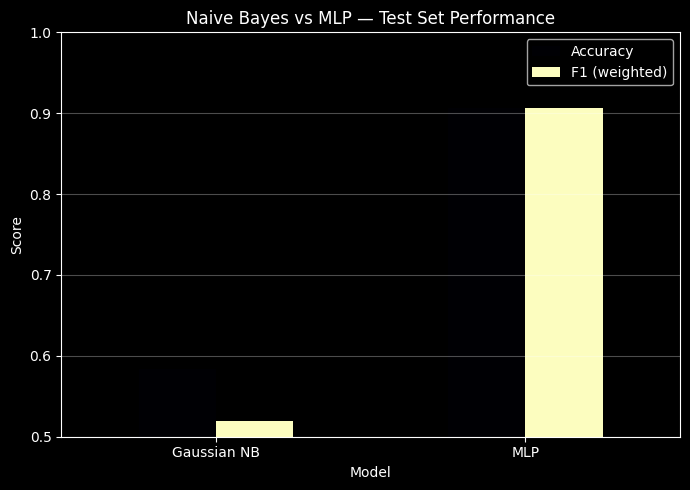

In [12]:
results = pd.DataFrame({
    'Model':         ['Gaussian NB', 'MLP'],
    'Accuracy':      [accuracy_score(y_test, p) for p in [y_pred_nb, y_pred_mlp]],
    'F1 (weighted)': [f1_score(y_test, p, average='weighted') for p in [y_pred_nb, y_pred_mlp]],
}).set_index('Model')
print(results.round(4))

results.plot(kind='bar', figsize=(7,5), rot=0, colormap='magma')
plt.title('Naive Bayes vs MLP — Test Set Performance')
plt.ylabel('Score'); plt.ylim(0.5, 1.0); plt.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()